### Visual comparison across ranks

In [10]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from src.io_utils import load_grayscale
from src.compression import compress_grayscale
from src.metrics import compression_ratio, psnr, ssim

In [12]:
image_path = PROJECT_ROOT / "data" / "raw" / "human.jpg"
image = load_grayscale(str(image_path))
print(image.shape)

(400, 600)


In [29]:
k = [5, 10, 20, 50, 100]
for i in k:
    compressed_image = compress_grayscale(image, i)
    compressed_image = np.clip(compressed_image, 0, 255).astype(np.uint8)
    print(f"Compression ratio for k={i}: {compression_ratio(image.shape, i)}")
    print(f"PSNR for k={i}: {psnr(image, compressed_image)}")
    print(f"SSIM for k={k}: {ssim(image, compressed_image)}") 


Compression ratio for k=5: 47.952047952047955
PSNR for k=5: 29.636471516320732
SSIM for k=[5, 10, 20, 50, 100]: 0.7431478825617357
Compression ratio for k=10: 23.976023976023978
PSNR for k=10: 31.70261122087766
SSIM for k=[5, 10, 20, 50, 100]: 0.7962102899725383
Compression ratio for k=20: 11.988011988011989
PSNR for k=20: 33.573523815144036
SSIM for k=[5, 10, 20, 50, 100]: 0.8594473476419495
Compression ratio for k=50: 4.795204795204795
PSNR for k=50: 37.71579444587514
SSIM for k=[5, 10, 20, 50, 100]: 0.9436901794167323
Compression ratio for k=100: 2.3976023976023977
PSNR for k=100: 42.428347381558176
SSIM for k=[5, 10, 20, 50, 100]: 0.981063115408243


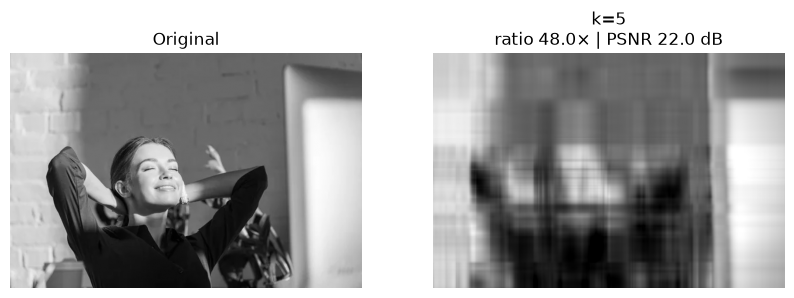

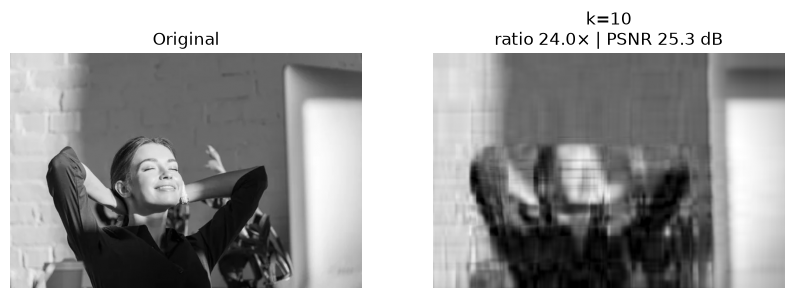

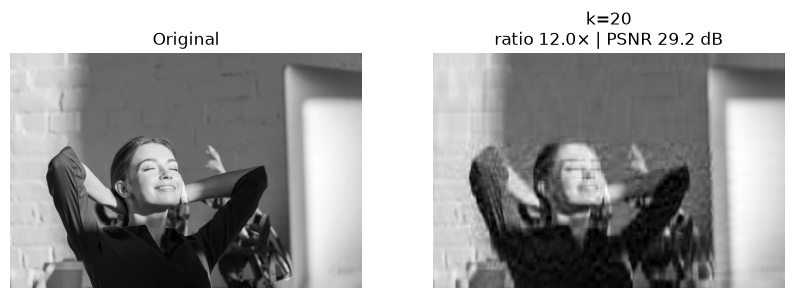

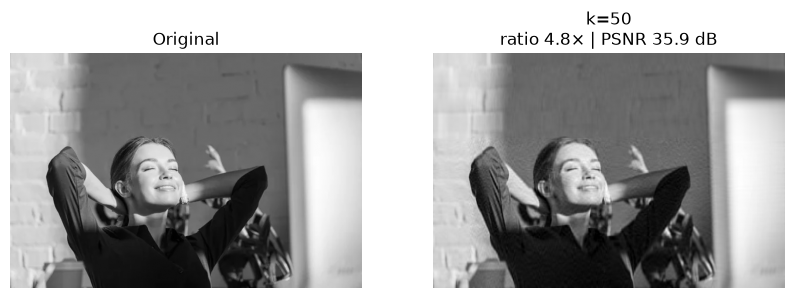

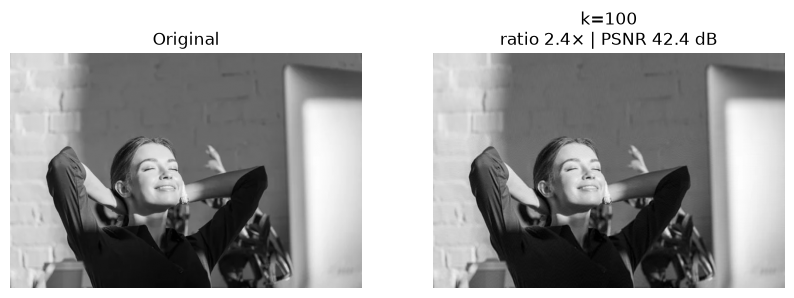

In [30]:
for i in k:
    compressed_image = compress_grayscale(image, i)
    ratio = compression_ratio(image.shape, i)
    p = psnr(image, compressed_image)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray', vmin=0, vmax=255)
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(compressed_image, cmap='gray', vmin=0, vmax=255)
    plt.title(f'k={i}\nratio {ratio:.1f}× | PSNR {p:.1f} dB')
    plt.axis('off')

    plt.show()